### Exploratory Data Analysis

#### Understanding the cleaned London property dataset through visual analysis, finding patterns relevant to modeling, and generate insights for feature engineering.

#### Importing Packages and Loading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

In [10]:
# Visuals Settings
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

In [3]:
# Paths
project_root = Path(".").resolve().parent
processed_path = project_root / "data" / "processed" / "london_clean.parquet"
figures_dir = project_root / "reports" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

In [4]:
# Data Frame
df = pd.read_parquet(processed_path)

In [5]:
df

,price,date_of_transfer,postcode,property_type,old_new,duration,district
0,215000,2025-01-31,E3 2PQ,F,N,L,TOWER HAMLETS
1,349000,2025-12-22,E17 7LB,F,N,L,WALTHAM FOREST
2,540000,2025-12-16,NW4 3PG,S,N,F,BARNET
3,460000,2025-12-15,E2 8FZ,F,N,L,HACKNEY
4,265000,2025-12-19,E14 9BF,F,N,L,TOWER HAMLETS
...,...,...,...,...,...,...,...
72587,393800,2025-06-11,E10 7PE,F,N,L,WALTHAM FOREST
72588,388000,2025-05-29,RM13 9SN,S,N,F,HAVERING
72589,358000,2025-06-05,RM3 7DX,T,N,F,HAVERING
72590,1095000,2025-01-03,E18 2PS,S,N,F,REDBRIDGE


In [6]:
df.dtypes

price                        int64
date_of_transfer    datetime64[ns]
postcode                    object
property_type             category
old_new                   category
duration                  category
district                  category
dtype: object

 #### Price Distribution

In [14]:
# Quick Stats
print(f"  Date range:  {df['date_of_transfer'].min().date()} to {df['date_of_transfer'].max().date()}")
print(f"  Price range: £{df['price'].min():,} to £{df['price'].max():,}")
print(f"  Median price: £{df['price'].median():,.0f}")
print(f"  Boroughs: {df['district'].nunique()}")


print(df['property_type'].value_counts())

print("\nNew vs existing builds:")
print(df['old_new'].value_counts())

print("\nFreehold vs leasehold:")
print(df['duration'].value_counts())

  Date range:  2025-01-01 to 2025-12-31
  Price range: £72,500 to £10,000,000
  Median price: £525,000
  Boroughs: 33
property_type
F    36826
T    20901
S    11427
D     3438
Name: count, dtype: int64

New vs existing builds:
old_new
N    70588
Y     2004
Name: count, dtype: int64

Freehold vs leasehold:
duration
L    37622
F    34970
Name: count, dtype: int64


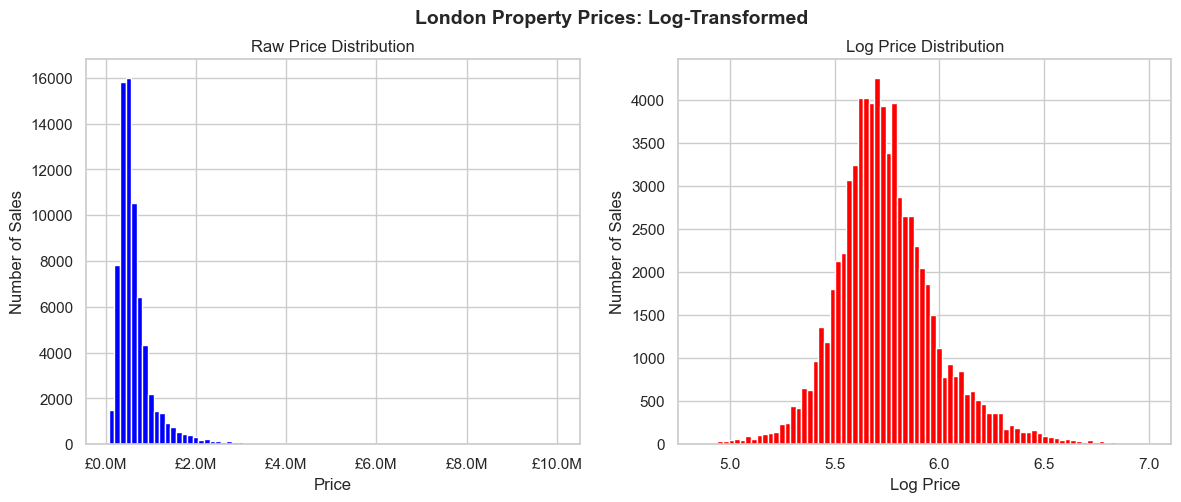

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Raw Prices in Pounds
axes[0].hist(df["price"], bins=80, color="blue")
axes[0].set_title("Raw Price Distribution")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Number of Sales")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))

# Right: Log Transformed Prices
axes[1].hist(np.log10(df["price"]), bins=80, color="red")
axes[1].set_title("Log Price Distribution")
axes[1].set_xlabel("Log Price")
axes[1].set_ylabel("Number of Sales")

plt.suptitle('London Property Prices: Log-Transformed', fontsize=14, fontweight='bold')

# Saving Figure
save_path = figures_dir / "01_price_distribution.png"
plt.savefig(save_path, dpi=150)

plt.show()

In [49]:
raw_price = df["price"].describe()
print("Raw price (£):")
print(raw_price.apply(lambda x: f"{x:,.0f}"))

log_price = np.log10(df['price'])
print("\nlog10(price):")
print(log_price.describe().round(2))

Raw price (£):
count        72,592
mean        669,450
std         577,476
min          72,500
25%         398,000
50%         525,000
75%         740,000
max      10,000,000
Name: price, dtype: object

log10(price):
count    72592.00
mean         5.75
std          0.24
min          4.86
25%          5.60
50%          5.72
75%          5.87
max          7.00
Name: price, dtype: float64


#### Prices by Borough

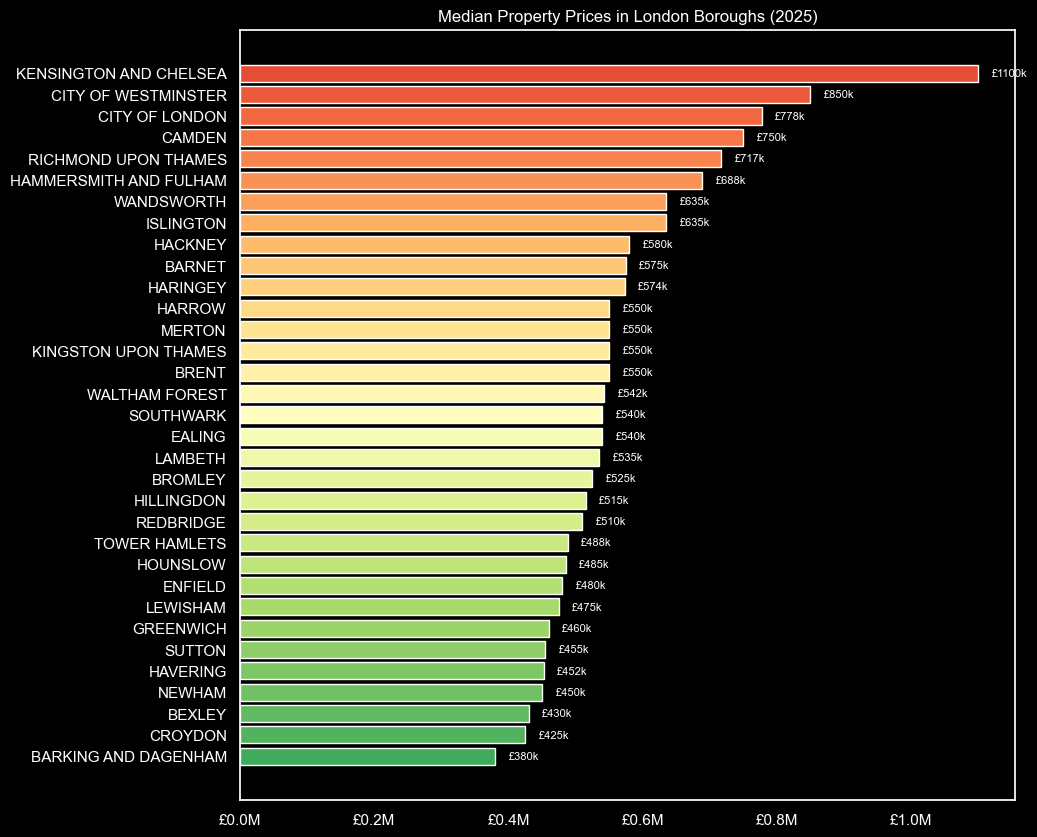

In [190]:
borough_median = (
    df.groupby("district", observed=True)["price"]
    .median()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 10))
colours = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(borough_median)))
ax.barh(borough_median.index, borough_median.values, color=colours, edgecolor="white")
ax.set_title("Median Property Prices in London Boroughs (2025)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
for i, (district, val) in enumerate(borough_median.items()):
    ax.text(val + 20_000, i, f'£{val/1000:.0f}k', va='center', fontsize=8)
ax.grid(False)
# Saving Figure
save_path = figures_dir / "02_price_by_borough.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')

#### Price by Property Type

C:\Users\Abdul Qudus\AppData\Local\Temp\ipykernel_15272\3487896996.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([type_labels.get(t, t) for t in order])


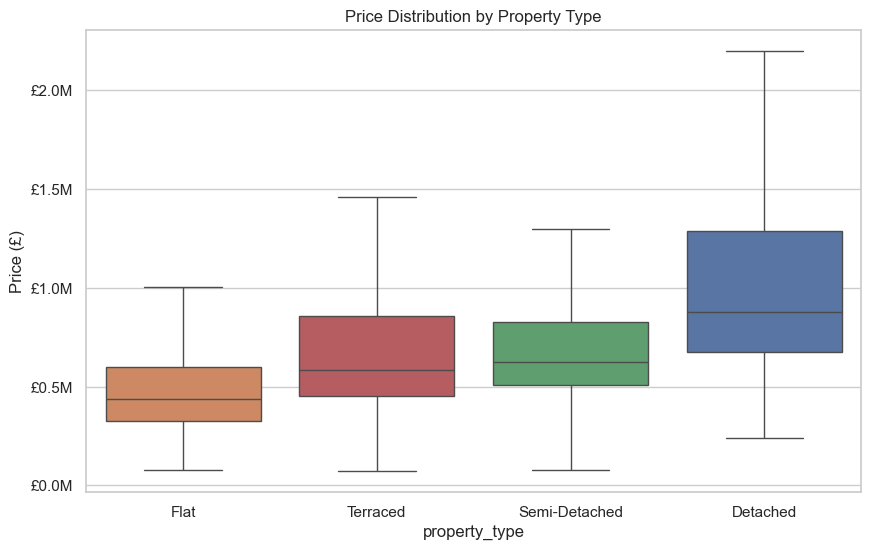

In [95]:
type_labels = {"F": "Flat", "T": "Terraced", "S": "Semi-Detached", "D": "Detached"}

fig, ax = plt.subplots(figsize=(10, 6))

# Order from cheapest to most expensive by Median
order = df.groupby("property_type", observed=True)["price"].median().sort_values().index.tolist()

sns.boxplot(
    data=df,
    x="property_type",
    y="price",
    order=order,
    ax=ax,
    showfliers=False,
    hue="property_type",
    legend=False,
)

# Mapping x-axis labels to readable names
ax.set_xticklabels([type_labels.get(t, t) for t in order])
ax.set_title("Price Distribution by Property Type")
ax.set_ylabel("Price (£)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))

save_path = figures_dir/"03_price_by_property_type.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')

#### Prices across 2025

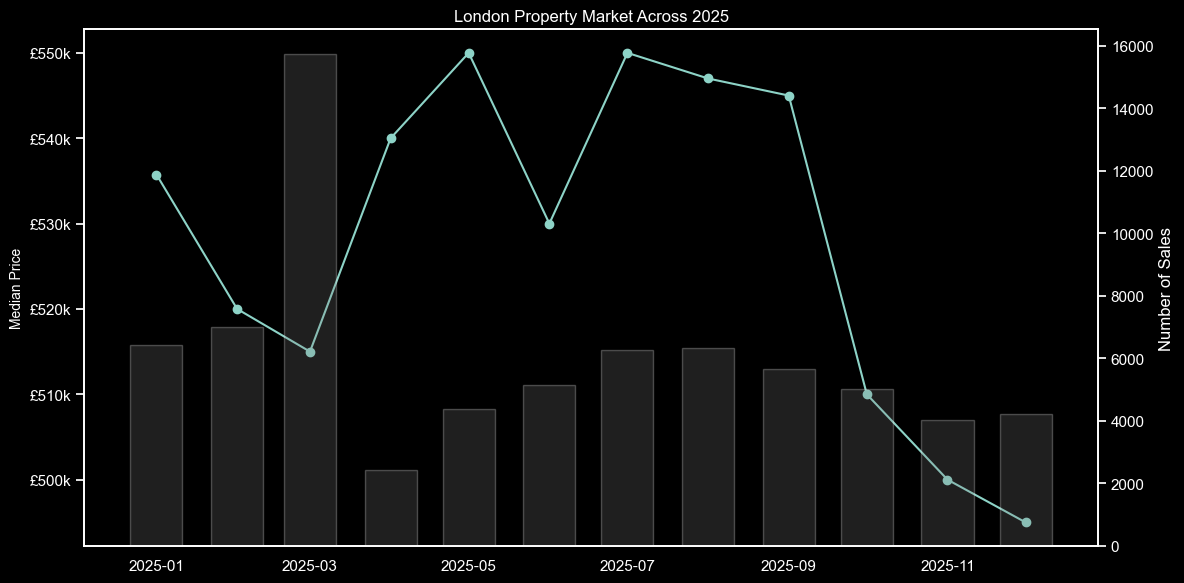

In [144]:
monthly_data = (
    df.assign(month=df['date_of_transfer'].dt.to_period('M'))
    .groupby('month', observed=True)['price']
    .agg(['median', 'count'])
    .reset_index()
)
monthly_data['month'] = monthly_data['month'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.grid(False)
# Left Axis: Median Price (Lines)
ax1.plot(monthly_data['month'], monthly_data["median"],
         marker="o", label="Median Price")
ax1.set_ylabel("Median Price", fontsize=10)
ax1.tick_params(axis='y')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1000:.0f}k'))

# Right Axis: Number of Sales (bars)
ax2 = ax1.twinx()
ax2.bar(monthly_data['month'], monthly_data['count'], alpha=0.25, width=20, color="tab:grey")
ax2.set_ylabel("Number of Sales")
ax2.tick_params(axis='y')
ax2.grid(False)
plt.title('London Property Market Across 2025')
fig.tight_layout()

save_path = figures_dir/"04_monthly_trend.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')

#### New Build vs Existing & Freehold vs Leasehold

C:\Users\Abdul Qudus\AppData\Local\Temp\ipykernel_15272\147970537.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Existing', 'New build'])
C:\Users\Abdul Qudus\AppData\Local\Temp\ipykernel_15272\147970537.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Freehold', 'Leasehold'])


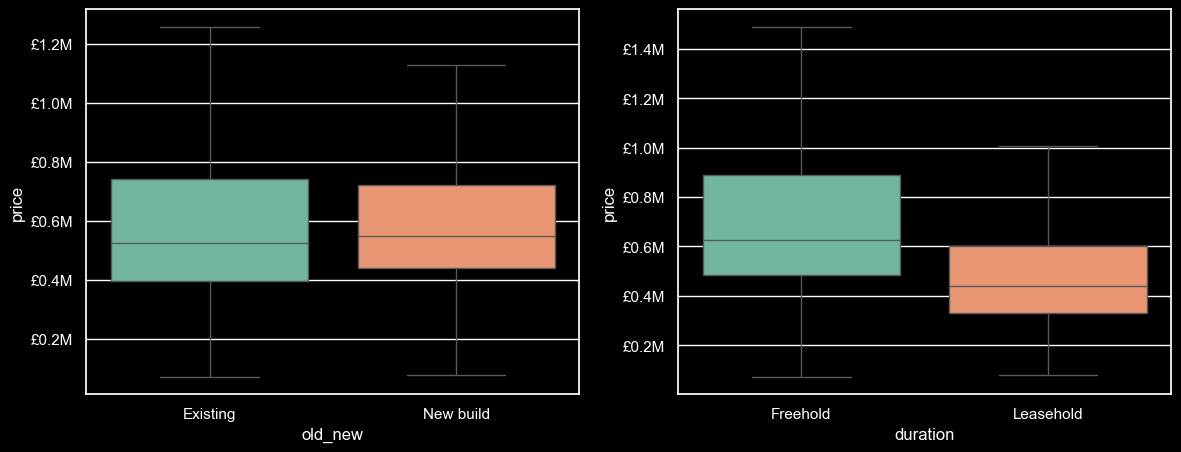

In [164]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: New vs Existing
sns.boxplot(
    data=df, x='old_new', y='price',
    order=['N', 'Y'], ax=axes[0],
    palette='Set2', showfliers=False,
    hue='old_new', legend=False,
)
axes[0].set_xticklabels(['Existing', 'New build'])
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))

# Right: freehold vs leasehold
sns.boxplot(
    data=df, x='duration', y='price',
    order=['F', 'L'], ax=axes[1],
    palette='Set2', showfliers=False,
    hue='duration', legend=False,
)
axes[1].set_xticklabels(['Freehold', 'Leasehold'])
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))

plt.tight_layout

save_path = figures_dir/"05_categorical_features.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')

#### Prices by Borough & Property Type

In [180]:
pivot = (
    df.pivot_table(
        index='district',
        columns='property_type',
        values='price',
        aggfunc='median',
        observed=True,
    )
    # Reorder columns from cheap to expensive
    [['F', 'T', 'S', 'D']]
    # Sort boroughs by overall median
    .assign(_overall=lambda d: d.mean(axis=1))
    .sort_values('_overall', ascending=False)
    .drop(columns='_overall')
)

# Rename column codes to readable names
pivot.columns = ['Flat', 'Terraced', 'Semi', 'Detached']

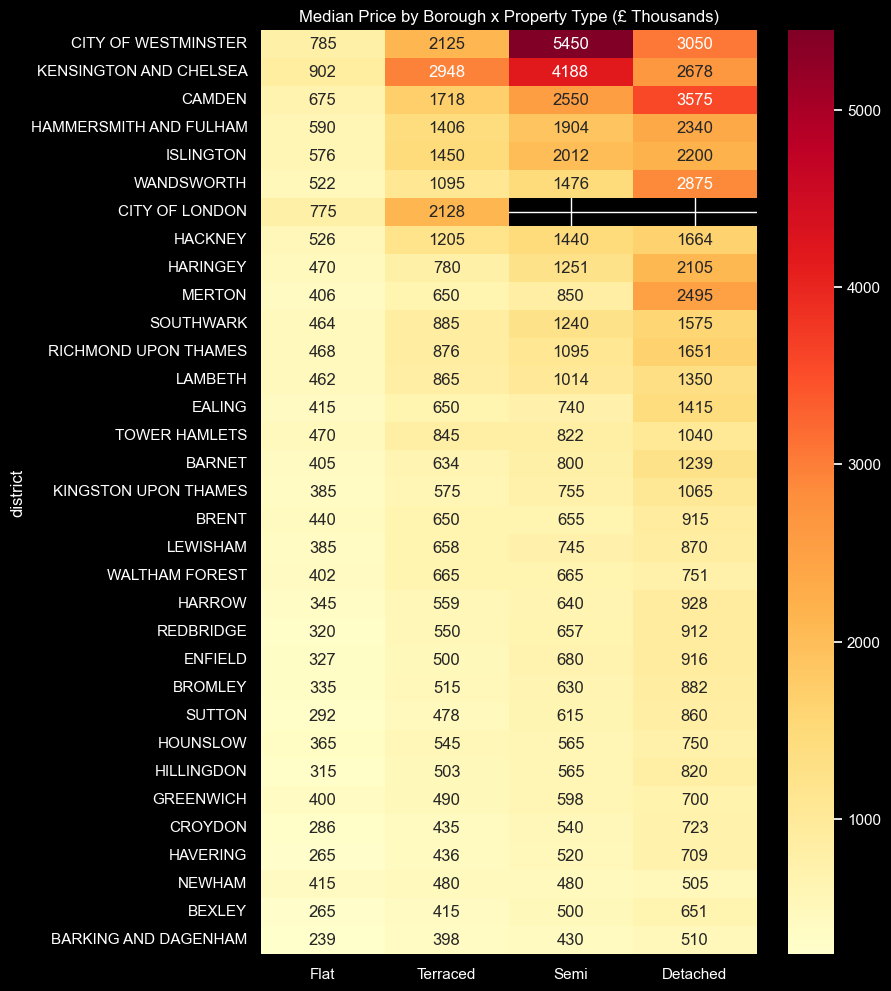

In [184]:
fig, ax = plt.subplots(figsize=(8,12))

sns.heatmap(
    pivot/1000, # Show in thousands for readability
    annot=True, fmt='.0f', cmap="YlOrRd", ax=ax,
)
ax.set_title("Median Price by Borough x Property Type (£ Thousands)")

save_path = figures_dir/"06_borough_property_heatmap.png"
plt.savefig(save_path, dpi=150, bbox_inches='tight')

### Summary:

#### Target Distribution

Median price is £525,000 with a range between £72,500 and £10,000,000.

Distribution is heavily right-skewed. The mean (£669,450) is 27.5% higher than the median, due to a long tail of high end sales.

Log10 transformation collapses this spread (raw std/mean ratio = 0.86 and log10 std = 0.24), giving us an almost normal distribution.

The decision is to train regression models using log transformed price rather than raw price, so that the loss function optimizes for relative error rather than absolute error.

#### Boroughs

Across the 33 London boroughs, the gap between the cheapest and most expensive borough is 3 times higher.

Central west boroughs such as Kensington & Chelsea, Westminster, Camden sit at the top. Outer east boroughs like Barking & Dagenham, Bexley, Havering are at the bottom.

This makes boroughs a very important categorical feature for the models.

#### Property and Sale Types
The market is dominated by flats and the prices also climb in this sequence: Flats = 50.7%, Terraced = 28.8%, Semi-Detached = 15.7%, Detached = 4.7%.

Detached homes make up under 5% of sales and not surprisingly they mostly occur in outer boroughs.

Less than 3% of sales in 2025 were new builds.

Freehold vs Leasehold split is almost 50/50. In London, flats are usually leasehold while outer boroughs houses are freehold.
Freehold properties are also more expensive due to factors such as land ownership value.